# Unsupervised Learning Model and Metrics

wanted to use spectral clustering or affinity propagation, but both always kill the kernel & I haven't found a way around it

In [ ]:
from util.met_cleaning import clean_met_data
from util.preprocessing import unsupervised_preprocessing
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import pandas as pd

# import warnings

# warnings.filterwarnings('ignore')

139

In [2]:
df = clean_met_data()

In [3]:
X = unsupervised_preprocessing(df)

## K-Means Clustering

In [4]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

In [5]:
df['significance_cluster_kmeans'] = kmeans

In [6]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(X)

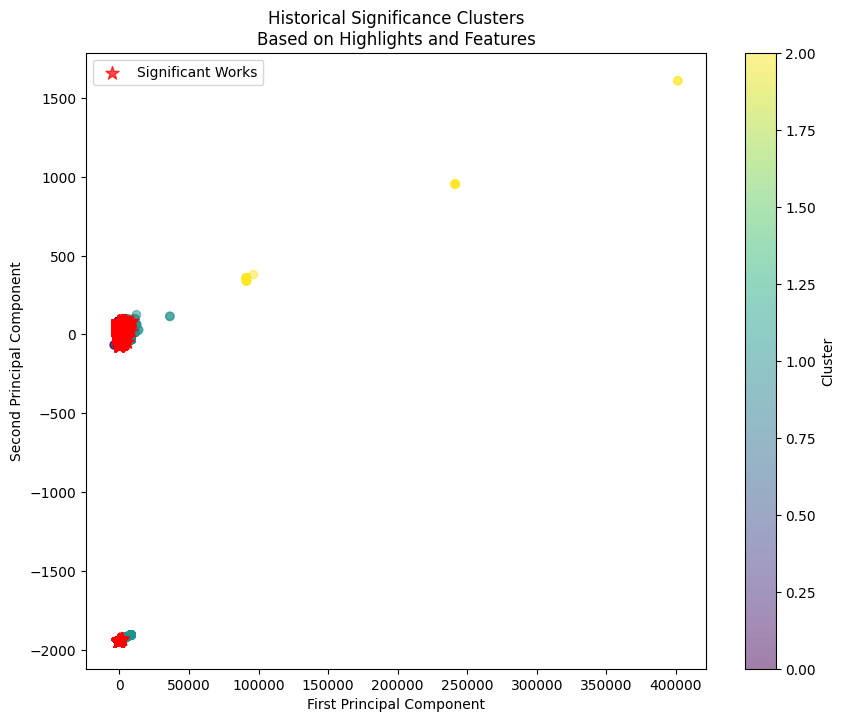

In [8]:
# Plot results 
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=kmeans, cmap='viridis', alpha=0.5)
plt.title('Historical Significance Clusters\nBased on Highlights and Features')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter, label='Cluster')

# Add special markers for highlighted works
highlight_mask = df['is_significant']
plt.scatter(features_pca[highlight_mask, 0], features_pca[highlight_mask, 1], 
           color='red', marker='*', s=100, label='Significant Works', alpha=0.7)
plt.legend()
plt.show()


In [9]:
print("\n K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    print(f"Number of significant artworks: {len(cluster_items[cluster_items['is_significant'] == True])}")  # noqa: E712
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    print(f"Most common country: {Counter(cluster_items['mapped_country'])}%")
    cultures = cluster_items['culture'].value_counts().head(3)
    print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 K-Means Cluster Analysis:

Cluster 0 (408496 items):
Number of significant artworks: 7827
Average age: 270.9 years
Most common country: Counter({'United States': 114507, 'France': 64860, 'United Kingdom': 36346, 'Italy': 34620, nan: 32614, 'Japan': 22937, 'Germany': 18919, 'China': 14907, 'Netherlands': 11935, 'Iran': 7183, 'Spain': 4600, 'India': 3994, 'Egypt': 3748, 'Belgium': 3356, 'Mexico': 3071, 'Austria': 2914, 'Indonesia': 2783, 'Peru': 2164, 'Russia': 1851, 'Switzerland': 1658, 'Czechia': 1459, 'Turkey': 1232, 'Ireland': 993, 'Canada': 908, 'Papua New Guinea': 881, 'Nigeria': 663, 'Korea': 610, 'Syria': 580, 'DR Congo': 545, 'Tibet': 537, 'Denmark': 532, 'Sweden': 516, 'Greece': 492, 'Hungary': 462, 'Iraq': 438, 'Thailand': 414, 'Mali': 407, 'Ivory Coast': 352, 'Philippines': 340, 'Colombia': 318, 'Morocco': 277, 'Cameroon': 255, 'Nepal': 226, 'Bolivia': 217, 'Portugal': 208, 'Australia': 206, 'Costa Rica': 206, 'Poland': 188, 'Myanmar': 185, 'Svalbard and Jan Mayen': 180, 'A

## DBSCAN Clustering

In [10]:
dbscan = DBSCAN(eps=1.5).fit_predict(features_pca)

need to do hyperparameter tuning to see best eps value, or can do multiple to see what different patterns it can identify, maybe use OPTICS?

In [11]:
df['significance_cluster_dbscan'] = dbscan

In [12]:
print("\n DBSCAN Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_dbscan'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    print(f"Number of significant artworks: {len(cluster_items[cluster_items['is_significant'] == True])}")  # noqa: E712
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    print(f"Most common country: {Counter(cluster_items['mapped_country'])}%")
    cultures = cluster_items['culture'].value_counts().head(3)
    print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))


 DBSCAN Cluster Analysis:

Cluster 0 (354087 items):
Number of significant artworks: 5079
Average age: 203.7 years
Most common country: Counter({'United States': 113158, 'France': 59993, 'United Kingdom': 34794, nan: 29079, 'Italy': 28417, 'Japan': 17782, 'Germany': 15264, 'China': 10714, 'Netherlands': 9880, 'Spain': 3467, 'Belgium': 2987, 'India': 2845, 'Mexico': 2203, 'Austria': 1926, 'Indonesia': 1765, 'Russia': 1711, 'Iran': 1465, 'Switzerland': 1429, 'Czechia': 1374, 'Turkey': 1025, 'Ireland': 922, 'Canada': 888, 'Papua New Guinea': 864, 'Nigeria': 631, 'DR Congo': 527, 'Denmark': 515, 'Sweden': 480, 'Greece': 454, 'Ivory Coast': 352, 'Hungary': 340, 'Mali': 333, 'Tibet': 317, 'Philippines': 305, 'Cameroon': 250, 'Morocco': 249, 'Korea': 209, 'Portugal': 192, 'Bolivia': 190, 'Australia': 182, 'Poland': 171, 'Peru': 170, 'Svalbard and Jan Mayen': 166, 'Ghana': 154, 'Finland': 151, 'Egypt': 141, 'Malaysia': 136, 'Benin': 123, 'Myanmar': 122, 'Algeria': 119, 'Thailand': 111, 'Burki